In [29]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.datasets import WikiCS
from torch_geometric.transforms import NormalizeFeatures, RandomLinkSplit
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score

In [30]:
save_path = '../WikiCS/WikiCS_data.pt'
save_dir = os.path.dirname(save_path)

In [31]:
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

In [32]:
if os.path.exists(save_path):
    print(f"Loading data from {save_path}...")
    data = torch.load(save_path, weights_only=False)
    num_features = data.x.shape[1]
    num_classes = int(data.y.max()) + 1
else:
    print("Data not found locally. Downloading WikiCS...")
    dataset = WikiCS(root='/tmp/WikiCS', transform=NormalizeFeatures())
    data = dataset[0]
    torch.save(data, save_path)
    print(f"Data saved to {save_path}")
    num_features = dataset.num_features
    num_classes = dataset.num_classes

Loading data from ../WikiCS/WikiCS_data.pt...


In [33]:
transform = RandomLinkSplit(is_undirected=True, add_negative_train_samples=False)
train_data, val_data, test_data = transform(data)

In [34]:
class RecommenderGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(0.5)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return prob_adj

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RecommenderGNN(num_features, 128, 64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

In [36]:
def get_link_labels(pos_edge_index, neg_edge_index):
    num_links = pos_edge_index.size(1) + neg_edge_index.size(1)
    labels = torch.zeros(num_links, device=device)
    labels[:pos_edge_index.size(1)] = 1.
    return labels

In [37]:
def train():
    model.train()
    optimizer.zero_grad()
    
    z = model.encode(train_data.x, train_data.edge_index)
    
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index, 
        num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1)
    )
    
    edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1)
    edge_labels = get_link_labels(train_data.edge_label_index, neg_edge_index)
    
    out = model.decode(z, edge_label_index)
    loss = F.binary_cross_entropy_with_logits(out, edge_labels)
    
    loss.backward()
    optimizer.step()
    return loss

In [38]:
@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)    
    out = model.decode(z, data.edge_label_index).sigmoid()
    return roc_auc_score(data.edge_label.cpu(), out.cpu())

In [39]:
print("\nTraining Multimodal Recommendation Baseline (Link Prediction)...")

best_val_auc = 0
start_patience = 0
PATIENCE_LIMIT = 20

loss_history = []
val_auc_history = []

for epoch in range(1, 101):
    loss = train()
    val_auc = test(val_data)
    
    loss_history.append(loss.item())
    val_auc_history.append(val_auc)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        start_patience = 0
    else:
        start_patience += 1
        
    if start_patience >= PATIENCE_LIMIT:
        print(f'Early stopping at epoch {epoch} with Best Val AUC: {best_val_auc:.4f}')
        break
        
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val AUC: {val_auc:.4f}')


Training Multimodal Recommendation Baseline (Link Prediction)...
Epoch: 010, Loss: 0.6356, Val AUC: 0.8802
Epoch: 020, Loss: 0.6059, Val AUC: 0.8780
Early stopping at epoch 27 with Best Val AUC: 0.8805


In [40]:
test_auc = test(test_data)
print(f'\nFinal Test AUC: {test_auc:.4f}')


Final Test AUC: 0.8653


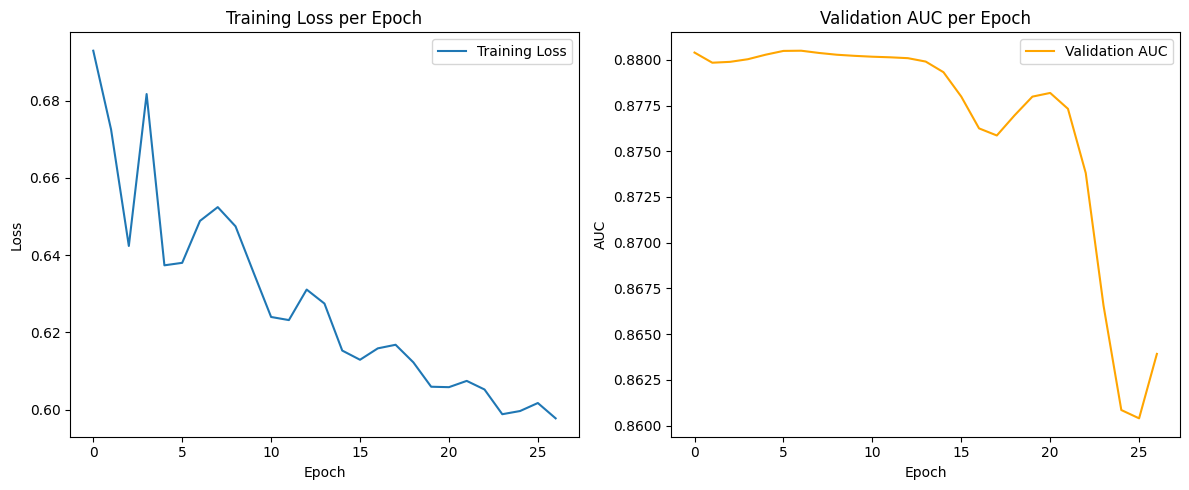

In [41]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_auc_history, label='Validation AUC', color='orange')
plt.title('Validation AUC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
import json
import requests

metadata_url = "https://raw.githubusercontent.com/pmernyei/wiki-cs-dataset/master/dataset/metadata.json"

print("Fetching Wikipedia titles...")
response = requests.get(metadata_url)
metadata = response.json()

node_titles = [node['title'] for node in metadata['nodes']]
label_names = metadata['labels']

print(f"Successfully loaded {len(node_titles)} article titles.")

Fetching Wikipedia titles...
Successfully loaded 11701 article titles.


In [49]:
@torch.no_grad()
def human_recommend(node_index, top_k=5):
    model.eval()
    
    z = model.encode(train_data.x, train_data.edge_index)
    
    target_z = z[node_index].unsqueeze(0)
    scores = torch.matmul(target_z, z.t()).squeeze()
    
    scores[node_index] = -1e10
    
    top_values, top_indices = torch.topk(scores, top_k)
    
    target_title = node_titles[node_index]
    target_label = label_names[str(data.y[node_index].item())]
    
    print(f"\nTarget Article: '{target_title}'")
    print(f"Category: {target_label}")
    print("-" * 40)
    print(f"Top {top_k} Recommendations:")
    
    for i in range(top_k):
        idx = top_indices[i].item()
        title = node_titles[idx]
        score = top_values[i].item()
        label = label_names[str(data.y[idx].item())]
        
        print(f"{i+1}. {title} (Score: {score:.2f}) | Category: {label}")

human_recommend(100)


Target Article: 'Magma_(computer_algebra_system)'
Category: Programming language topics
----------------------------------------
Top 5 Recommendations:
1. Mirror_driver (Score: 0.00) | Category: Operating systems
2. Memory_Technology_Device (Score: 0.00) | Category: Operating systems
3. Kernel_preemption (Score: 0.00) | Category: Computer architecture
4. Wide-issue (Score: 0.00) | Category: Computer architecture
5. Live_File_System (Score: 0.00) | Category: Computer file systems
